# Visit-count confound diagnostics (SANITY)

Reloads a previously trained longitudinal trajectory model (the `latest/` run of `SOURCE_EXPERIMENT`) **without retraining** and quantifies the visit-count confound — whether the number of visits (which differs systematically between converters and non-converters) drives the early-detection AUC and the model's predictions. Model-agnostic: every model-specific operation goes through the adapter hooks (`adapters/`), all computation lives in `common/visit_confound.py`.

Driven by `run_experiment.py` via the `sanity-visit-confound-*` entries in `experiments.yaml`. See `common/VISIT_COUNT_CONFOUND.md` for the interpretation.

In [1]:
# === Papermill parameters (injected by run_experiment.py) ===
EXPERIMENT_ID = None
MODE = None
MODEL = None
ADAPTER = None                # adapter registry key; None -> defaults to MODEL
DATASET = None
SEED = 42
SOURCE_EXPERIMENT = None      # id whose outputs/<id>/latest/ run is reloaded
WANDB_ENABLED = True
OUTPUT_DIR = None
RESOLVED_CONFIG = None
RUN_DIR = None                # set by the runner: where artifacts go
RUN_NAME = None               # set by the runner: the run name
# Injected by the runner for every experiment; unused here (this notebook reloads a
# trained model rather than training one) — declared only to silence papermill.
GAAE_CHECKPOINT_PATH = None
THRESHOLD_MODE = None
FIXED_THRESHOLD = None

In [2]:
# Parameters
EXPERIMENT_ID = "sanity-visit-confound-gegru"
MODE = "sanity"
MODEL = "GELSTM"
ADAPTER = "gelstm"
DATASET = "DELCODE_WHOLE_BRAIN"
SEED = 42
GAAE_CHECKPOINT_PATH = None
SOURCE_EXPERIMENT = "gegru-trajectory-whole-brain"
THRESHOLD_MODE = None
FIXED_THRESHOLD = None
WANDB_ENABLED = True
OUTPUT_DIR = "outputs/sanity-visit-confound-gegru"
RESOLVED_CONFIG = {"epochs": 100, "lr": 0.001, "weight_decay": 0.0, "rnn_type": "lstm", "batch_size": 16, "grad_clip": 1.0, "early_stopping_patience": 20, "use_scheduler": True, "seed": 42, "threshold_mode": "youden", "fixed_threshold": 0.5, "lr_factor": 0.5, "lr_patience": 5, "lr_min": 1e-06, "classifier_norm": "none", "use_time_delta": True, "zero_time_delta": False, "graph_pool": "mean", "dim_filter": None, "shuffle_order": False, "shuffle_rng": None}
RUN_DIR = "/mnt/e/fyassine/ad-early-detection/CLASSIFIER/outputs/sanity-visit-confound-gegru/runs/winter-flame-2-d9655b0db-2026-06-21_14-02-12"
RUN_NAME = "winter-flame-2-d9655b0db-2026-06-21_14-02-12"


In [3]:
import sys
from pathlib import Path
repo_root = Path('/mnt/e/fyassine/ad-early-detection')
model_root = Path('/mnt/e/fyassine/ad-early-detection/CLASSIFIER')
if str(model_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
    sys.path.insert(0, str(model_root))

In [4]:
# reproducibility seeding — must run before datasets or models.
from CLASSIFIER.common.seeding import set_seed, make_rng, make_torch_generator
set_seed(SEED)
rng = make_rng(SEED)
torch_gen = make_torch_generator(SEED)

In [5]:
import json, os, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from datetime import datetime

from common.sanity import run_full_audit
from common.provenance import region_from_data_root
from common.crossval import Bundle
from common.early_detection import early_detection_table, trajectory_frame
from common.visit_confound import (
    summarize_visit_counts, cohort_composition_table, early_detection_fixed_cohort,
    prob_vs_visit_count, within_subject_prob_slopes, prob_spread_summary,
)
from common.calibration import apply_temperature, expected_calibration_error
from adapters import get_adapter, read_run_threshold
warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## Configuration

In [7]:
from DATA.src.splitting.load_splits import splits_dir, split_csv_paths

WB_DATA_ROOT = '/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__fc_wholebrain_sch200_flat__/matrices'
METADATA_DIR = '/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__fc_wholebrain_sch200_flat__/metadata'
COHORTS_CSV  = os.path.join(METADATA_DIR, 'cohorts.csv')
SPLITS_DIR   = str(splits_dir('downstream'))
TRAIN_CSV    = os.path.join(SPLITS_DIR, 'train.csv')
VAL_CSV      = os.path.join(SPLITS_DIR, 'val.csv')
TEST_CSV     = os.path.join(SPLITS_DIR, 'test.csv')
DATA_INFO    = region_from_data_root(WB_DATA_ROOT)
REGION       = DATA_INFO['region']
CONFIG_PATH  = model_root / 'configs' / 'gaae_delcode_whole_brain.json'
print(f"Region: {REGION}  atlas={DATA_INFO['atlas']}")

Region: wholebrain  atlas=sch200


In [8]:
# split-hygiene audit — hard-fails if any subject crosses splits.
_ = run_full_audit(split_csv_paths('downstream'))

[SANITY] Split sizes: {'train': 99, 'val': 34, 'test': 34}
[SANITY] Pairwise-disjoint: OK


## Resolve source run

Reload the `latest/` run of `SOURCE_EXPERIMENT`: its `run_summary.json` gives the GAAE checkpoint + the exact `training_config` the model was trained with (so the adapter is rebuilt identically — `rnn_type`, `use_fdr`, … all match).

In [9]:
if not SOURCE_EXPERIMENT:
    raise ValueError(
        "SANITY_VISIT_COUNT_CONFOUND requires SOURCE_EXPERIMENT; set "
        "'source_experiment:' on the entry in experiments.yaml."
    )
src_root = model_root / 'outputs' / SOURCE_EXPERIMENT
latest = src_root / 'latest'
if latest.exists():
    SRC_RUN_DIR = latest.resolve()
elif (src_root / 'latest.txt').is_file():
    SRC_RUN_DIR = src_root / 'runs' / (src_root / 'latest.txt').read_text().strip()
else:
    raise FileNotFoundError(f'No latest run for {SOURCE_EXPERIMENT!r} under {src_root}.')
if not SRC_RUN_DIR.is_dir():
    raise FileNotFoundError(f'Resolved source run dir missing: {SRC_RUN_DIR}')
print('Source run:', SRC_RUN_DIR)

with open(SRC_RUN_DIR / 'run_summary.json') as f:
    SRC_SUMMARY = json.load(f)
SRC_TRAIN_CONFIG = dict(SRC_SUMMARY.get('training_config') or {})
SRC_MODEL_CONFIG = dict(SRC_SUMMARY.get('model_config') or {})
GAAE_CKPT_PATH = SRC_SUMMARY.get('gaae_checkpoint')
if not GAAE_CKPT_PATH or not Path(GAAE_CKPT_PATH).exists():
    raise FileNotFoundError(f'GAAE checkpoint from source run not found: {GAAE_CKPT_PATH}')
print('training_config keys:', sorted(SRC_TRAIN_CONFIG))
print('GAAE checkpoint   :', GAAE_CKPT_PATH)

Source run: /mnt/e/fyassine/ad-early-detection/CLASSIFIER/outputs/gegru-trajectory-whole-brain/runs/lucky-harbor-3-d9655b0db-2026-06-21_13-50-00
training_config keys: ['batch_size', 'classifier_hidden', 'classifier_norm', 'dim_filter', 'early_stopping_patience', 'epochs', 'fixed_threshold', 'freeze_encoder', 'grad_clip', 'graph_pool', 'learning_rate', 'lr', 'lr_factor', 'lr_min', 'lr_patience', 'lstm_dropout', 'lstm_hidden', 'lstm_layers', 'n_folds', 'rnn_type', 'seed', 'shuffle_order', 'shuffle_rng', 'standardize_features', 'threshold_mode', 'use_class_cost_weights', 'use_scheduler', 'use_time_delta', 'weight_decay', 'zero_time_delta']
GAAE checkpoint   : /mnt/e/fyassine/ad-early-detection/CLASSIFIER/notebooks/checkpoints/checkpoints_gaae_whole_brain/ethereal-planet-16_2026-06-10_12-31-05/model_ethereal-planet-16_2026-06-10_12-31-05.pth


In [10]:
if CONFIG_PATH.exists():
    with open(CONFIG_PATH) as f: hp = json.load(f)
else:
    hp = dict(latent_dim=64, hidden_dim=128, num_heads=2, cond_dim=2, dropout=0.3,
              adjacency_k=8, file_variant='z_transformed')
print('GAAE config:', hp)

GAAE config: {'seed': 100, 'batch_size': 64, 'learning_rate': 0.001, 'weight_decay': 0.001, 'adj_loss_weight': 0.2, 'epochs': 500, 'early_stopping_patience': 25, 'latent_dim': 64, 'hidden_dim': 128, 'num_heads': 2, 'cond_dim': 2, 'dropout': 0.3, 'adjacency_k': 16, 'num_workers': 8, 'file_variant': 'z_transformed'}


## Rebuild adapter + reload trained model

In [11]:
adapter = get_adapter(ADAPTER or MODEL)(
    gaae_ckpt_path=str(GAAE_CKPT_PATH), gaae_hp=hp, train_config=SRC_TRAIN_CONFIG,
    data_root=WB_DATA_ROOT, cohorts_csv=COHORTS_CSV, device=device, rng=rng,
)
print('Adapter:', type(adapter).__name__, ' model_tag=', adapter.model_tag)
prepare_data         = adapter.prepare_data
eval_split           = adapter.eval_split
truncate_to_n_visits = adapter.truncate_to_n_visits
per_visit_probs      = adapter.per_visit_probs

Adapter: GELSTMAdapter  model_tag= gelstm


In [12]:
train_df = pd.read_csv(TRAIN_CSV); val_df = pd.read_csv(VAL_CSV); test_df = pd.read_csv(TEST_CSV)
cv_pool_df = pd.concat([train_df, val_df], ignore_index=True)
CV_BUNDLE   = prepare_data(cv_pool_df)   # encodes CV pool first (locks GEC max_visits)
TEST_BUNDLE = prepare_data(test_df)
_all_items  = list(CV_BUNDLE.items) + list(TEST_BUNDLE.items)
ALL_BUNDLE  = Bundle([it['label'] for it in _all_items],
                     [it['subject_id'] for it in _all_items], _all_items)
print(f'CV subjects: {len(CV_BUNDLE)}  Test subjects: {len(TEST_BUNDLE)}  All: {len(ALL_BUNDLE)}')

LongitudinalSubjectDataset[v2]: 133 subjects (54 converter, 79 stable MCI)
  Scans per subject: min=1  max=6  mean=3.0


LongitudinalSubjectDataset[v2]: 34 subjects (14 converter, 20 stable MCI)
  Scans per subject: min=1  max=6  mean=2.9


CV subjects: 133  Test subjects: 34  All: 167


In [13]:
STATE = adapter.load_state(SRC_RUN_DIR)
THRESHOLD = read_run_threshold(SRC_RUN_DIR)
print(f'Reloaded model state; threshold = {THRESHOLD:.4f}')

# Cross-check: reloaded test AUC must match the saved run (else the reload is wrong).
_chk = eval_split(STATE, TEST_BUNDLE, THRESHOLD, device=device)
_saved = (SRC_SUMMARY.get('metrics') or {}).get('test_auc', SRC_SUMMARY.get('test_auc'))
print(f"Reloaded test AUC = {_chk['auc']:.4f}   (saved: {_saved})")

Reloaded model state; threshold = 0.6594
[GAAE load] Loaded 76 parameters from /mnt/e/fyassine/ad-early-detection/CLASSIFIER/notebooks/checkpoints/checkpoints_gaae_whole_brain/ethereal-planet-16_2026-06-10_12-31-05/model_ethereal-planet-16_2026-06-10_12-31-05.pth


Reloaded test AUC = 0.8321   (saved: 0.8321428571428572)


In [14]:
# Load the run's post-hoc temperature (fit on OOF at training time). T<1 widens the
# spread; monotonic, so it never changes AUC or the thresholded decisions.
calib_path = SRC_RUN_DIR / 'calibration.json'
if calib_path.is_file():
    CALIB = json.load(open(calib_path))
    TEMPERATURE = float(CALIB.get('temperature', 1.0))
    print(f"Temperature={TEMPERATURE:.3f}  (OOF ECE {CALIB.get('ece_oof_raw')} -> {CALIB.get('ece_oof_cal')})")
else:
    CALIB = {'temperature': 1.0}
    TEMPERATURE = 1.0
    print('No calibration.json in source run -> T=1.0 (identity). Re-run the training to generate it.')

Temperature=0.742  (OOF ECE 0.14256537830303037 -> 0.13968785407310697)


## 1 — Do converters have fewer visits?

In [15]:
VC_ALL  = summarize_visit_counts(ALL_BUNDLE)
VC_TEST = summarize_visit_counts(TEST_BUNDLE)
print('Visit counts by group — full mci/converter dataset:')
display(VC_ALL)
print('Visit counts by group — held-out test split:')
display(VC_TEST)

Visit counts by group — full mci/converter dataset:


,group,n,mean,median,std,min,max,mwu_pvalue
0,converter,68,3.426471,3.0,1.459055,1,6,0.002204
1,non_converter,99,2.737374,2.0,1.619939,1,6,0.002204
2,overall,167,3.017964,3.0,1.588638,1,6,0.002204


Visit counts by group — held-out test split:


,group,n,mean,median,std,min,max,mwu_pvalue
0,converter,14,3.714286,3.5,1.489893,2,6,0.011002
1,non_converter,20,2.350000,2.0,1.182103,1,4,0.011002
2,overall,34,2.911765,3.0,1.464068,1,6,0.011002


## 2 — Per-N cohort composition vs the early-detection AUC

The variable-cohort early-detection table re-scores a *shrinking, self-selected* cohort at each N. The composition columns show how the class balance shifts, which is why per-N AUCs are not directly comparable.

In [16]:
ED_VAR  = early_detection_table(TEST_BUNDLE, eval_split, truncate_to_n_visits,
                                STATE, THRESHOLD, device=device)
COMP    = cohort_composition_table(TEST_BUNDLE, truncate_to_n_visits)
ed_df   = pd.DataFrame(ED_VAR)
comp_df = pd.DataFrame(COMP)
COMBINED = comp_df.merge(ed_df[['n_visits', 'auc', 'sensitivity', 'specificity']],
                         on='n_visits', how='left') if not ed_df.empty else comp_df
print('Per-N cohort composition + variable-cohort AUC:')
display(COMBINED)


Visits    N      AUC     Sens     Spec
----------------------------------------


     1   34   0.6071    0.643    0.400


     2   28   0.8316    0.714    0.786


     3   18   0.9250    0.600    1.000


     4   12   0.9429    0.571    1.000
Per-N cohort composition + variable-cohort AUC:


,n_visits,n_subjects,n_converters,n_nonconverters,frac_converter,auc,sensitivity,specificity
0,1,34,14,20,0.411765,0.607143,0.642857,0.400000
1,2,28,14,14,0.500000,0.831633,0.714286,0.785714
2,3,18,10,8,0.555556,0.925000,0.600000,1.000000
3,4,12,7,5,0.583333,0.942857,0.571429,1.000000
4,5,5,5,0,1.000000,NaN,NaN,NaN
5,6,2,2,0,1.000000,NaN,NaN,NaN


## 3 — Fixed-cohort early detection

Restrict to the deepest-followed subjects and truncate *them* to N=1..K, where K is the deepest depth at which the cohort still has both classes and enough subjects (anchoring to the raw maximum visit count would pick a tiny single-class tail). The cohort no longer changes across N, so this trend reflects information per visit, not a changing population. The fixed cohort can be small — read `n_subjects`.


Visits    N      AUC     Sens     Spec
----------------------------------------
     1   12   0.6286    0.571    0.400


     2   12   0.8000    0.714    0.800


     3   12   0.8857    0.571    1.000


     4   12   0.9429    0.571    1.000
Fixed-cohort early detection:


,n_visits,n_subjects,auc,sensitivity,specificity
0,1,12,0.628571,0.571429,0.4
1,2,12,0.800000,0.714286,0.8
2,3,12,0.885714,0.571429,1.0
3,4,12,0.942857,0.571429,1.0


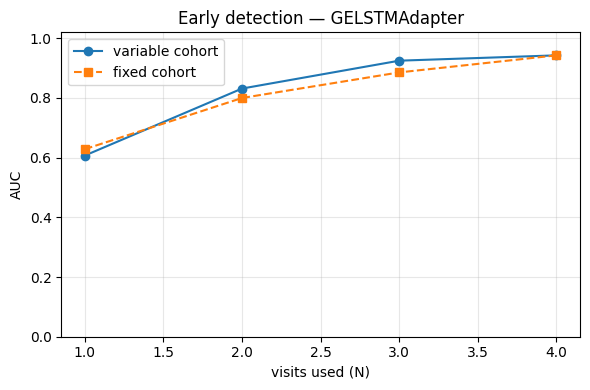

In [17]:
ED_FIXED = early_detection_fixed_cohort(TEST_BUNDLE, eval_split, truncate_to_n_visits,
                                        STATE, THRESHOLD, device=device)
fixed_df = pd.DataFrame(ED_FIXED)
print('Fixed-cohort early detection:')
display(fixed_df)

fig_ed, ax = plt.subplots(figsize=(6, 4))
if not ed_df.empty:
    ax.plot(ed_df['n_visits'], ed_df['auc'], 'o-', label='variable cohort')
if not fixed_df.empty:
    ax.plot(fixed_df['n_visits'], fixed_df['auc'], 's--', label='fixed cohort')
ax.set_xlabel('visits used (N)'); ax.set_ylabel('AUC'); ax.set_ylim(0, 1.02)
ax.set_title(f'Early detection — {type(adapter).__name__}'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4 — Does the model read visit count? (prediction vs n_scans)

Full-trajectory P(converter) against the number of visits. A correlation that survives *within* a label is the shortcut signal — the model using visit count rather than biology.

Spearman r(prob, n_scans):
  overall        r=-0.076  p=0.671  n=34
  converter      r=0.108  p=0.714  n=14
  non_converter  r=-0.681  p=0.001  n=20


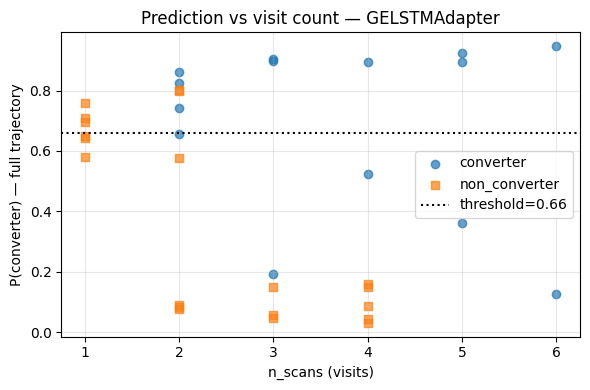

In [18]:
PROB_DF, SPEARMAN = prob_vs_visit_count(TEST_BUNDLE, per_visit_probs, STATE, device=device)
print('Spearman r(prob, n_scans):')
for grp, s in SPEARMAN.items():
    print(f"  {grp:14s} r={s['r']:.3f}  p={s['p']:.3f}  n={s['n']}")

fig_prob, ax = plt.subplots(figsize=(6, 4))
for lab in (1, 0):
    sub = PROB_DF[PROB_DF['label'] == lab]
    ax.scatter(sub['n_scans'], sub['prob'], marker=('o' if lab == 1 else 's'),
               label=('converter' if lab == 1 else 'non_converter'), alpha=0.7)
ax.axhline(THRESHOLD, ls=':', c='k', label=f'threshold={THRESHOLD:.2f}')
ax.set_xlabel('n_scans (visits)'); ax.set_ylabel('P(converter) — full trajectory')
ax.set_title(f'Prediction vs visit count — {type(adapter).__name__}')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 5 — Probability spread / separation

Spread — raw full-trajectory prediction:
{
  "converter": {
    "n": 14,
    "mean": 0.6968751272984913,
    "std": 0.28359609354329574,
    "iqr": 0.3401344418525696
  },
  "non_converter": {
    "n": 20,
    "mean": 0.35901672737672924,
    "std": 0.314031569470612,
    "iqr": 0.5790972542017698
  },
  "overall": {
    "n": 34,
    "mean": 0.498134892050396,
    "std": 0.341977014633516,
    "iqr": 0.6699345447123051
  },
  "separation": 0.3378583999217621
}

Separation:  raw=0.338  ->  calibrated (T=0.742)=0.365
Test ECE:    raw=0.236  ->  calibrated=0.269


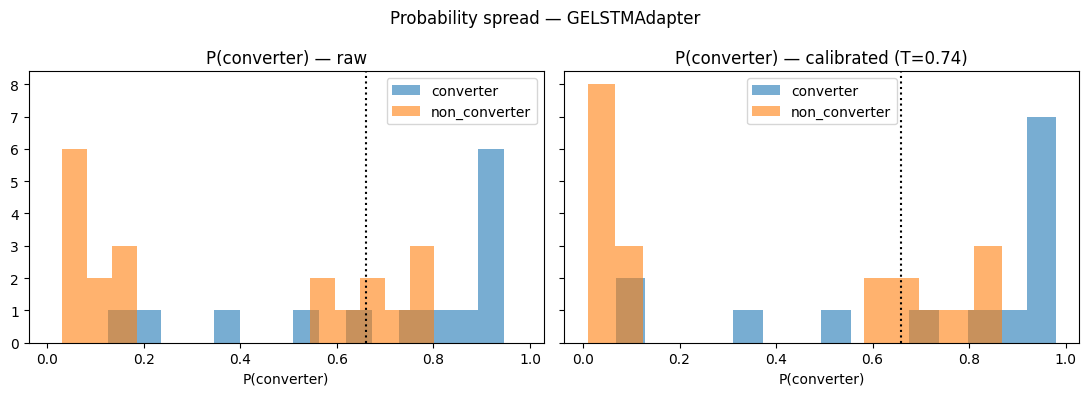

In [19]:
TRAJ_DF = trajectory_frame(TEST_BUNDLE, per_visit_probs, STATE, device=device)
SPREAD_FINAL = prob_spread_summary(PROB_DF)
SPREAD_TRAJ  = prob_spread_summary(TRAJ_DF)
print('Spread — raw full-trajectory prediction:'); print(json.dumps(SPREAD_FINAL, indent=2))

# Apply temperature scaling (the spread "fix"): monotonic -> AUC unchanged.
PROB_DF_CAL = PROB_DF.assign(prob=apply_temperature(PROB_DF['prob'].to_numpy(), TEMPERATURE))
SPREAD_FINAL_CAL = prob_spread_summary(PROB_DF_CAL)
ECE_RAW = expected_calibration_error(PROB_DF['prob'].to_numpy(), PROB_DF['label'].to_numpy())
ECE_CAL = expected_calibration_error(PROB_DF_CAL['prob'].to_numpy(), PROB_DF_CAL['label'].to_numpy())
print(f"\nSeparation:  raw={SPREAD_FINAL['separation']:.3f}  ->  calibrated (T={TEMPERATURE:.3f})={SPREAD_FINAL_CAL['separation']:.3f}")
print(f"Test ECE:    raw={ECE_RAW:.3f}  ->  calibrated={ECE_CAL:.3f}")

fig_spread, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
for ax, df, ttl in [(axes[0], PROB_DF, 'raw'), (axes[1], PROB_DF_CAL, f'calibrated (T={TEMPERATURE:.2f})')]:
    for lab in (1, 0):
        ax.hist(df[df['label'] == lab]['prob'], bins=15, alpha=0.6,
                label=('converter' if lab == 1 else 'non_converter'))
    ax.axvline(THRESHOLD, ls=':', c='k'); ax.set_title(f'P(converter) — {ttl}')
    ax.set_xlabel('P(converter)'); ax.legend()
fig_spread.suptitle(f'Probability spread — {type(adapter).__name__}'); plt.tight_layout(); plt.show()

In [20]:
# 6 — Shortcut vs evidence accumulation: within-subject P(converter) slope as a
# subject's OWN visits accumulate. A pure count shortcut would leave each subject flat
# (slope ~0); evidence accumulation drifts consistently (e.g. negative for non-converters).
SLOPE_DF, SLOPE_STATS = within_subject_prob_slopes(TEST_BUNDLE, per_visit_probs, STATE, device=device)
print('Within-subject slope of P(converter) vs visit index:')
for grp, s in SLOPE_STATS.items():
    print(f"  {grp:14s} median_slope={s['median_slope']:.4f}  frac_negative={s['frac_negative']}  n={s['n']}")
print('\nRead with the between-subject Spearman above: strong between-subject correlation '
      'but flat within-subject slopes => count shortcut; consistent within-subject drift '
      '=> evidence accumulation. Corroborate with the sanity-gelstm-ablations '
      'shuffle-order / zero-delta_t run.')

Within-subject slope of P(converter) vs visit index:
  overall        median_slope=-0.0085  frac_negative=0.5  n=28
  converter      median_slope=0.0642  frac_negative=0.14285714285714285  n=14
  non_converter  median_slope=-0.1983  frac_negative=0.8571428571428571  n=14

Read with the between-subject Spearman above: strong between-subject correlation but flat within-subject slopes => count shortcut; consistent within-subject drift => evidence accumulation. Corroborate with the sanity-gelstm-ablations shuffle-order / zero-delta_t run.


## Save diagnostics

In [21]:
CONFOUND = {
    'experiment_id': EXPERIMENT_ID, 'source_experiment': SOURCE_EXPERIMENT,
    'source_run_dir': str(SRC_RUN_DIR), 'model': type(adapter).__name__,
    'threshold': float(THRESHOLD), 'temperature': float(TEMPERATURE),
    'visit_counts_all': VC_ALL.to_dict('records'),
    'visit_counts_test': VC_TEST.to_dict('records'),
    'cohort_composition': COMP,
    'early_detection_variable': ED_VAR,
    'early_detection_fixed': ED_FIXED,
    'prob_vs_visit_count_spearman': SPEARMAN,
    'within_subject_slopes': SLOPE_STATS,
    'prob_spread_final': SPREAD_FINAL,
    'prob_spread_final_cal': SPREAD_FINAL_CAL,
    'prob_spread_trajectory': SPREAD_TRAJ,
    'ece_raw': float(ECE_RAW), 'ece_cal': float(ECE_CAL),
}
out_dir = Path(RUN_DIR) if RUN_DIR else (
    model_root / 'outputs' / (EXPERIMENT_ID or 'sanity-visit-confound') / 'standalone')
out_dir.mkdir(parents=True, exist_ok=True)
with open(out_dir / 'confound_results.json', 'w') as f:
    json.dump(CONFOUND, f, indent=2)
fig_ed.savefig(out_dir / 'early_detection_fixed_vs_variable.png', dpi=120, bbox_inches='tight')
fig_prob.savefig(out_dir / 'prob_vs_visit_count.png', dpi=120, bbox_inches='tight')
fig_spread.savefig(out_dir / 'prob_spread_raw_vs_calibrated.png', dpi=120, bbox_inches='tight')

def _mean(recs, grp):
    return next((r['mean'] for r in recs if r['group'] == grp), float('nan'))
conv_gap = _mean(CONFOUND['visit_counts_all'], 'converter') - _mean(CONFOUND['visit_counts_all'], 'non_converter')
summary = {
    'experiment_id': EXPERIMENT_ID, 'run_name': RUN_NAME,
    'source_experiment': SOURCE_EXPERIMENT,
    'timestamp': datetime.now().isoformat(timespec='seconds'),
    'metrics': {
        'converter_visit_count_gap': float(conv_gap),
        'visit_count_mwu_pvalue': float(CONFOUND['visit_counts_all'][0]['mwu_pvalue']),
        'prob_nscans_spearman_overall': float(SPEARMAN['overall']['r']),
        'prob_nscans_spearman_converter': float(SPEARMAN['converter']['r']),
        'nonconv_within_subject_median_slope': float(SLOPE_STATS['non_converter']['median_slope']),
        'early_detection_auc_max_variable': float(max((r['auc'] for r in ED_VAR), default=float('nan'))),
        'early_detection_auc_max_fixed': float(max((r['auc'] for r in ED_FIXED), default=float('nan'))),
        'temperature': float(TEMPERATURE),
        'prob_separation': float(SPREAD_FINAL['separation']),
        'prob_separation_cal': float(SPREAD_FINAL_CAL['separation']),
        'ece_raw': float(ECE_RAW), 'ece_cal': float(ECE_CAL),
    },
}
with open(out_dir / 'run_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print('Saved confound diagnostics to', out_dir)

Saved confound diagnostics to /mnt/e/fyassine/ad-early-detection/CLASSIFIER/outputs/sanity-visit-confound-gegru/runs/winter-flame-2-d9655b0db-2026-06-21_14-02-12
